<a href="https://colab.research.google.com/github/StrawEater/PracticasPDI3erBimestre/blob/main/Tareas/Tarea_1/Tarea1_Ecualizacion_PDI2026_Realizar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Nombre del Grupo:***

***Integrantes:***

# **Tarea Ecualizacion y Modificacion de Histograma**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data, color, util, io, exposure
from matplotlib.gridspec import GridSpec
!wget -q https://raw.githubusercontent.com/leodomingue/test_clase_1/main/test_suma_acumulada.py -O test_suma_acumulada.py
!wget -q https://raw.githubusercontent.com/leodomingue/test_clase_1/main/test_ecualizar_imagen.py -O test_ecualizar.py

## 1. Fundamentos: Histograma y Ecualización Clásica

### Histograma y ecualizacion

El **histograma** de una imagen es una representación gráfica de la distribución de los valores de intensidad de píxeles en ella abstrayendola de su contenido. Por ejemplo, nos permite, a grandes rasgos, conocer si la imagen es oscura, brillante, con poco o buen contraste.

Por otro lado, la **ecualización del histograma** es una técnica que redistribuye los niveles de gris para obtener un histograma lo más uniforme posible, mejorando el contraste visual.

- **Imagen oscura:** Si el histograma se concentra en el lado izquierdo, la imagen tiene predominancia de tonos oscuros.
- **Imagen brillante:** Si el histograma se concentra en el lado derecho, la imagen está dominada por tonos claros.
- **Poco contraste:** Un histograma concentrado en un rango estrecho de valores indica una imagen con bajo contraste.
- **Buen contraste:** Un histograma distribuido de manera más uniforme sugiere una imagen con un buen rango de intensidades y, por lo tanto, un alto contraste visual.

En resumen, el histograma nos ofrece una **"sensación"** de la imagen, ya que nos permite entender de manera cuantitativa su iluminación, contraste y calidad visual.

### Formalización matemática

Si consideramos una imagen $M$ de $N$ píxeles, definimos su **histograma normalizado** (distribución de probabilidad) como:

$$ p_M(i) = \frac{h_M(i)}{N}, \quad i = 0, 1, \dots, 255 $$

donde $h_M(i)$ es el número de píxeles con intensidad $i$.

La **función de distribución acumulada (CDF)** se define como:

$$ F_M(t) = \sum_{i=0}^{t} p_M(i) $$

Esta función es monótona no decreciente y va de 0 a 1.

La **ecualización del histograma** consiste en aplicar la transformación:

$$ T[i] = \text{round}\big( F_M(i) \cdot 255 \big) $$

Es decir, para cada nivel de gris original $i$, se asigna el nuevo valor $T[i]$ basado en la probabilidad acumulada. Esto produce una imagen cuyo histograma tiende a ser uniforme, mejorando el contraste.

### 1.2 Carga y visualización de imágenes de ejemplo

In [ ]:
#Imagenes de ejemplo
imagenOscura = util.img_as_ubyte(io.imread("/content/imagen_oscura.avif", as_gray=True))
imagenSobreExpuesta = util.img_as_ubyte(io.imread("/content/ejemplo_playa.jpg", as_gray=True))
imagenPocoContraste = data.moon()
imagenContraste = util.img_as_ubyte((color.rgb2gray(data.coffee())))
imagenes_ejemplo = [imagenOscura, imagenSobreExpuesta, imagenPocoContraste, imagenContraste]

#Funcion para mostrar la imagen y su histograma
def mostrar_imagen_histograma(ax_imagen, ax_histograma, imagen, titulo):

  #Imagen
  ax_imagen.imshow(imagen, cmap='gray', clim=(0,255))
  ax_imagen.set_title(titulo)
  ax_imagen.axis('off')

  #Histograma
  ax_histograma.hist(imagen.ravel(), bins=256, range=(0,255), density=True, histtype='step', color='black')
  ax_histograma.set_title(f'Histograma de {titulo}')
  ax_histograma.grid(True)

  #Estadisticas
  media = np.mean(imagen)
  desv = np.std(imagen)
  ax_histograma.axvline(media, color='red', linestyle='--', label=f'Media = {media:.1f}')
  ax_histograma.legend()

  return media, desv


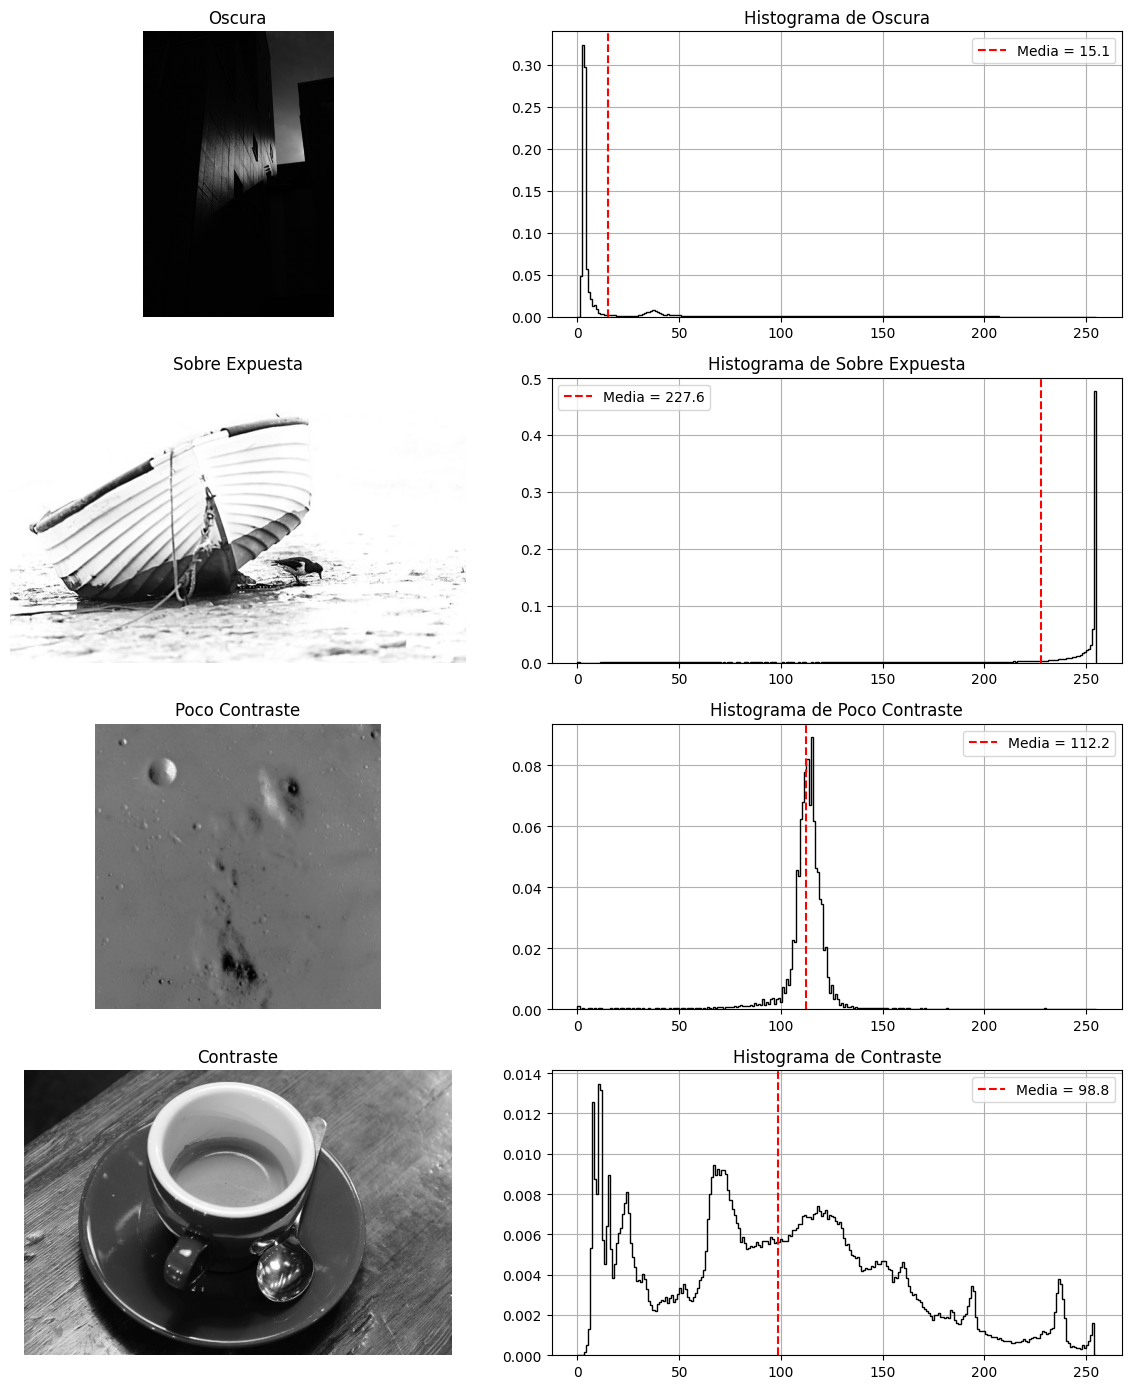

        Imagen      Media  Desviación Estándar
        Oscura  15.109313            32.414810
Sobre Expuesta 227.586690            58.084535
Poco Contraste 112.169571            13.330291
     Contraste  98.787971            58.899125


In [ ]:
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
estadisticas = []
for i, (imagen, titulo) in enumerate(zip(imagenes_ejemplo, ['Oscura', 'Sobre Expuesta', 'Poco Contraste', 'Contraste'])):
  media, desv = mostrar_imagen_histograma(axs[i,0], axs[i,1], imagen, titulo)
  estadisticas.append((titulo, media, desv))
plt.tight_layout()
plt.show()

df_estadisticas = pd.DataFrame(estadisticas, columns=['Imagen', 'Media', 'Desviación Estándar'])
print(df_estadisticas.to_string(index=False))

### Implementación de funciones base

In [ ]:
# Funcion que dada una imagen, devuelve su funcion de probabilidad (PDF)
def distribucionImagen(imagen):
  # Utilizando density=True, np realiza la normalizacion sobre la cantidad de pixels automaticamente
  return np.histogram(imagen.ravel(), bins=256, range=(0,255), density=True)[0]

#COMPLETAR
#Funcion que cada una distribucion normalizada, calcule la probabilidad acumulada hasta discho nivel de gris (CDF)
def calcularProbabilidadAcumulada(distribucion_normalizada: np.ndarray, nivelGris: int) -> float:
  """
  Calcula la probabilidad acumulada (CDF) hasta un nivel de gris dado

  Parámetros:
      distribucion_normalizada: array de 256 elementos que suma 1.
      nivelGris: nivel de gris hasta el cual se acumula.

  Retorna:
      float: probabilidad acumulada en el rango [0.0, 1.0].
  """
  #PASO 1: Asegurar que nivelGris sea un entero (por si viene como float)
  nivelGris = int(nivelGris)

  #PASO 2: Manejar casos fuera de rango (Cuales son sus limites y que deben devolver?)

  #PASO 3: Calcular la suma de probabilidad acumulada hasta nivel actual

  return suma

#Función que devuelve el vector de CDF para todos los niveles (0..255)
def crearGraficoSumAcumulada(distribucion):
  suma = np.zeros(distribucion.size)
  for i in range(256):
    suma[i] = calcularProbabilidadAcumulada(distribucion, i)
  return suma

def mostrarDistribucion(ax_hist, ax_cdf, imagen, titulo):
    distribucion = distribucionImagen(imagen)
    cdf = crearGraficoSumAcumulada(distribucion)

    #Histograma (PDF)
    ax_hist.set_title(f"Distribución {titulo}")
    ax_hist.grid(True)
    ax_hist.bar(range(256), distribucion, width=1, color='black')

    #CDF
    ax_cdf.set_title(f"Función acumulada {titulo}")
    ax_cdf.grid(True)
    ax_cdf.plot(range(256), cdf, color='black', label=f"CDF {titulo}")
    ax_cdf.plot([0, 255], [0, 1], color='orange', linestyle='--', label="Uniforme")
    ax_cdf.legend()

#### Test Acerca de calcularProbabilidadAcumulada

In [ ]:
import test_suma_acumulada
test_suma_acumulada.evaluar(calcularProbabilidadAcumulada)

----------------------------------------------------------------------
Ran 6 tests in 0.002s

OK



RESUMEN DE PRUEBAS
¡Todas las pruebas pasaron! La función es correcta.


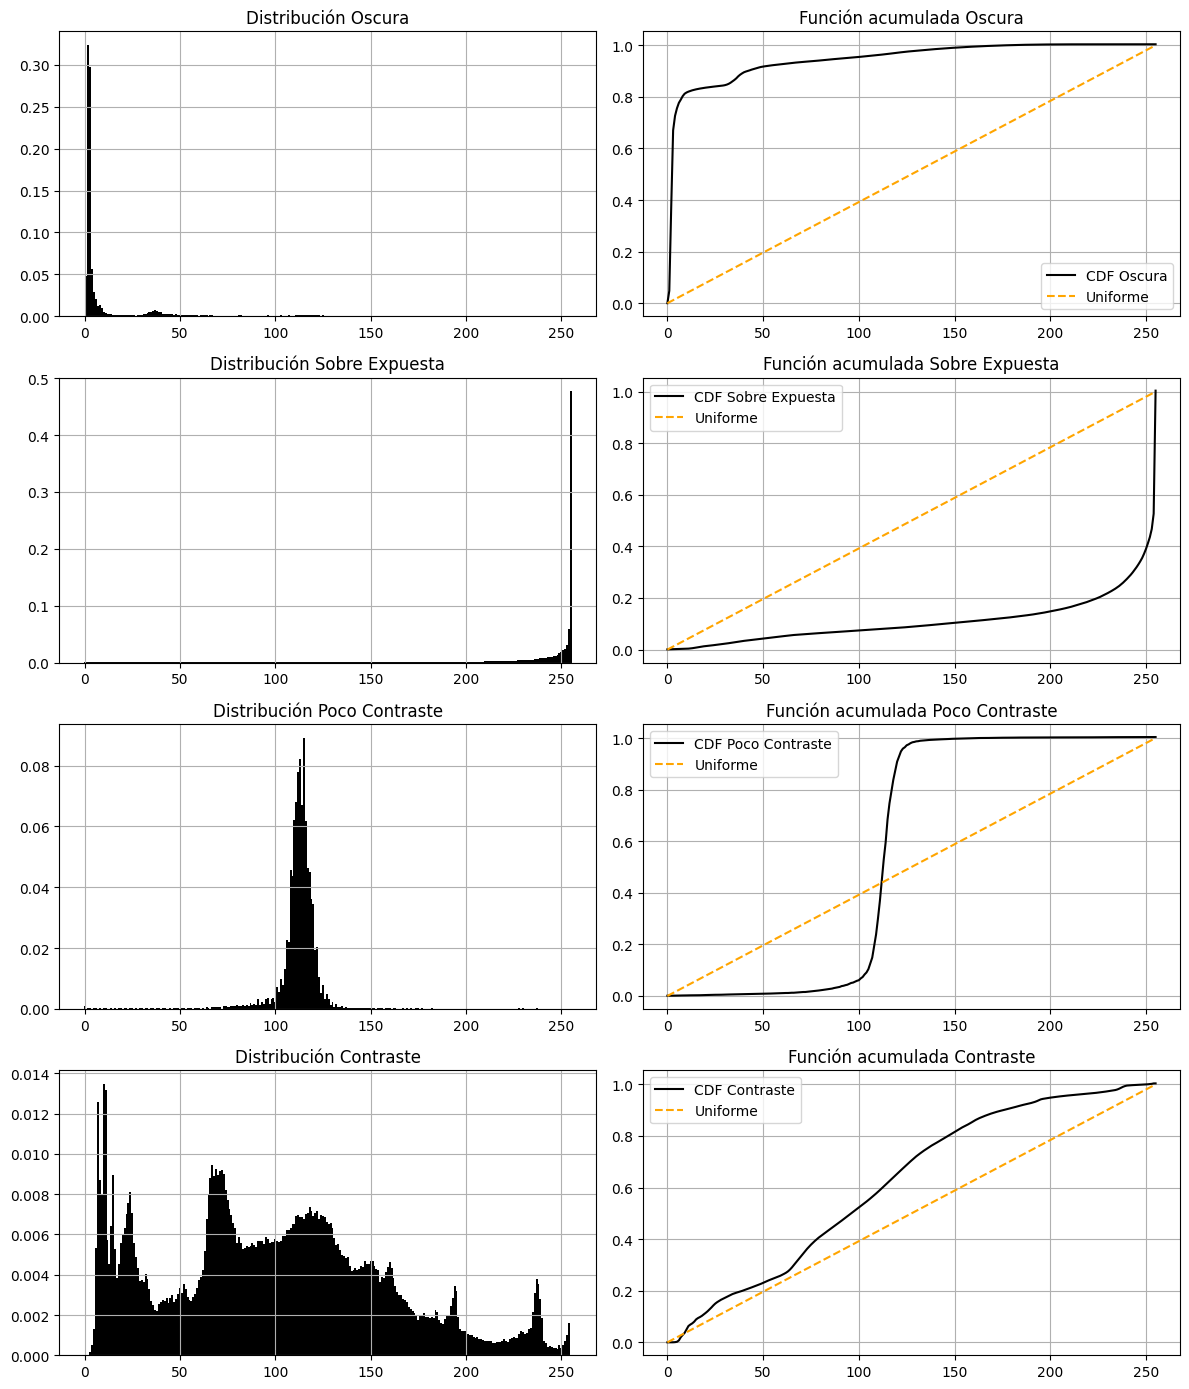

In [ ]:
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
for i, (imagen, titulo) in enumerate(zip(imagenes_ejemplo, ['Oscura', 'Sobre Expuesta', 'Poco Contraste', 'Contraste'])):
  mostrarDistribucion(axs[i,0], axs[i,1], imagen, titulo)
plt.tight_layout()
plt.show()

In [ ]:
def ecualizar_imagen(imagen: np.ndarray, histogramaH: np.ndarray)-> np.ndarray:
  """
  Aplica la ecualización del histograma usando el histograma de referencia `histogramaH`.

  Parámetros:
      imagen: numpy.ndarray (uint8), imagen en escala de grises.
      histogramaH: numpy.ndarray (float), histograma normalizado (suma = 1) de 256 bins.

  Retorna:
      numpy.ndarray (uint8), imagen ecualizada con valores en [0, 255].
  """
  #PASO 1: Copiar la imagen y pasarla a tipo float para operar con precisión (float64)
  imagen_float = imagen.astype(np.float64)

  #PASO 2: Crear una imagen de salida del mismo tamaño, inicializada en ceros

  #PASO 3: Recorrer todos los píxeles de la imagen y escalar cada nivel de gris original usando la CDF del histogramaH.
  #Fórmula: T[i] = round(F(i) * 255)

  #PASO Final: Convertir la imagen resultante a uint8, recortando valores fuera de rango y redondenado
  imagen_final = np.clip(np.round(imagen_ecualizada), 0, 255).astype(np.uint8)
  return imagen_final

In [ ]:
import test_ecualizar
test_ecualizar.evaluar(ecualizar_imagen, distribucionImagen)

----------------------------------------------------------------------
Ran 8 tests in 47.013s

OK



RESUMEN DE PRUEBAS: ECUALIZACIÓN DE IMAGEN
¡Todas las pruebas pasaron! La función de ecualización es correcta.


In [ ]:
def comparar_ecualizacion(imagen, histograma_ref=None, titulo="Imagen"):
    if histograma_ref is None:
        histograma_ref = distribucionImagen(imagen)

    #Ecualización nuestra
    img_eq = ecualizar_imagen(imagen, histograma_ref)
    #Ecualización de scikit-image
    img_eq_sk = util.img_as_ubyte(exposure.equalize_hist(imagen))

    #Creamos 2 filas y 3 columnas
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Comparación de ecualización - {titulo}', fontsize=14)

    axs[0,0].imshow(imagen, cmap='gray', clim=(0,255))
    axs[0,0].set_title('Original')
    axs[0,0].axis('off')

    axs[0,1].imshow(img_eq, cmap='gray', clim=(0,255))
    axs[0,1].set_title('Nuestra ecualización')
    axs[0,1].axis('off')

    axs[0,2].imshow(img_eq_sk, cmap='gray', clim=(0,255))
    axs[0,2].set_title('Ecualización scikit-image')
    axs[0,2].axis('off')


    axs[1,0].hist(imagen.ravel(), bins=256, range=(0,255), density=True, histtype='step', color='black')
    axs[1,0].set_title('Histograma original')
    axs[1,0].grid(True, alpha=0.3)

    axs[1,1].hist(img_eq.ravel(), bins=256, range=(0,255), density=True, histtype='step', color='red')
    axs[1,1].set_title('Histograma (nuestra)')
    axs[1,1].grid(True, alpha=0.3)

    axs[1,2].hist(img_eq_sk.ravel(), bins=256, range=(0,255), density=True, histtype='step', color='blue')
    axs[1,2].set_title('Histograma (scikit)')
    axs[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

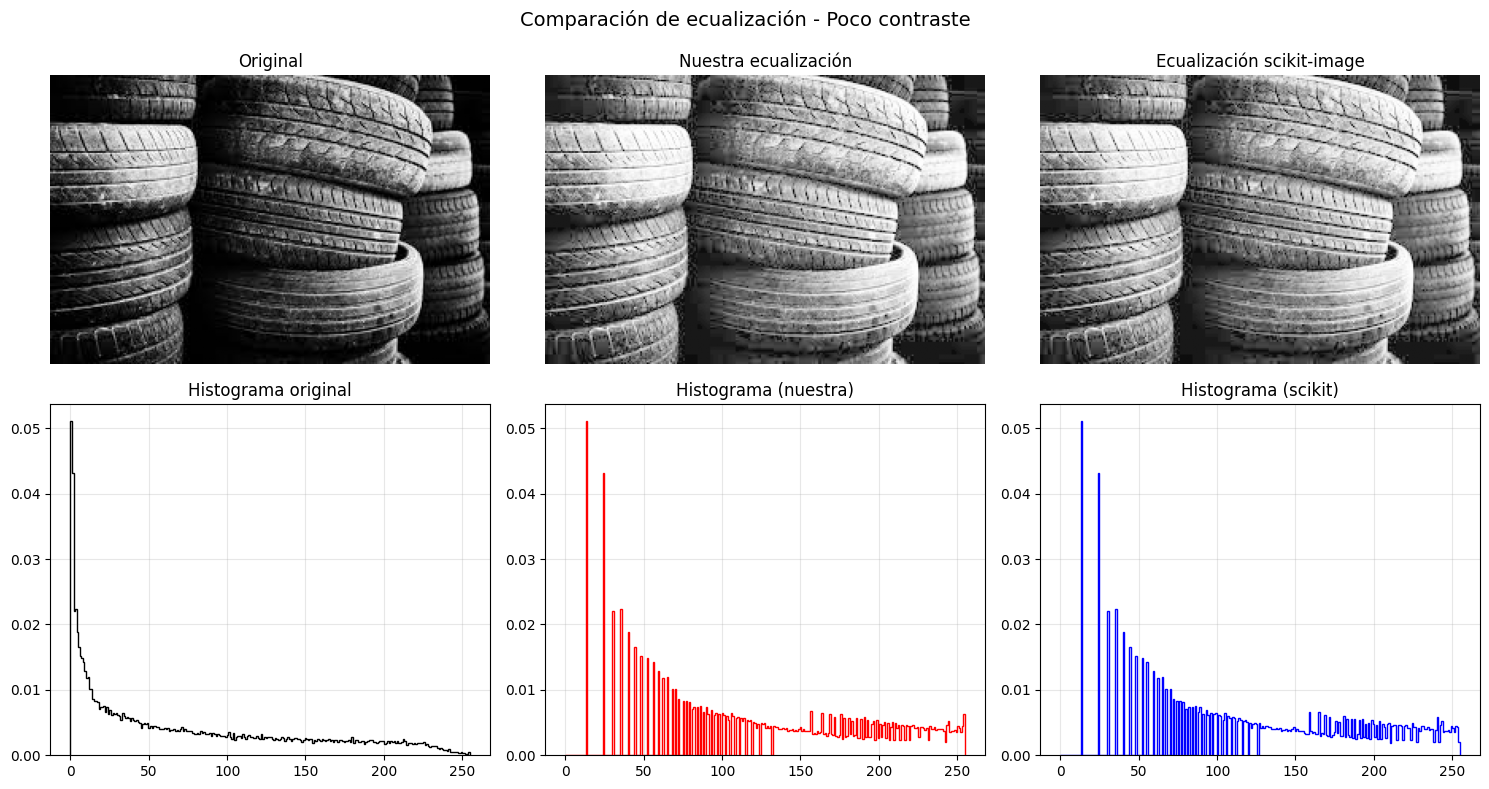

In [ ]:
fig = comparar_ecualizacion(imagenPocoContraste, titulo="Poco contraste")
plt.show()

## 2. A Histogram Modification Framework and Its Application for Image Contrast Enhancement



Aunque la ecualización de histograma es una herramienta flexible y eficiente para mejorar el contraste de las imágenes, en algunas ocasiones el resultado puede parecer poco natural. Esto se debe principalmente a los saltos abruptos en la función de mapeo T[n] (la CDF), que se acentúan cuando el histograma original presenta picos pronunciados, generando transiciones bruscas entre niveles de gris y una apariencia artificial.

El artículo "A Histogram Modification Framework and Its Application for Image Contrast Enhancement" propone un conjunto de técnicas que buscan mejorar los resultados de la ecualización, minimizando estos efectos negativos mediante términos de regularización que controlan el grado de modificación y la suavidad del histograma.

En esta tarea implementaremos tres de esas técnicas: Adjustable Histogram Equalization (AHE), Histogram Smoothing y Black and White Stretching.

###2.1 Motivación: saltos en la función de mapeo

La ecualización clásica produce una función de mapeo T[n] que es esencialmente la CDF escalada al rango 0-255. Esta función es monótona no decreciente, pero puede presentar saltos abruptos cuando el histograma original tiene picos pronunciados (por ejemplo, en imágenes con regiones homogéneas). Estos saltos implican que dos niveles de gris consecutivos pueden ser mapeados a valores muy diferentes, generando transiciones bruscas y un aspecto poco natural en la imagen ecualizada.

In [ ]:
def diagnostico_ecualizacion(img, histogramaH=None):
    #Vemos si hay histograma normalizado para ver si podes actuar
    if histogramaH is None:
        hist, _ = np.histogram(img.flatten(), bins=256, range=(0,256))
        histogramaH = hist / hist.sum()
    else:
        histogramaH = histogramaH / histogramaH.sum() if histogramaH.sum() != 0 else histogramaH

    #ecualizamos la imagen con nuestra funcion
    img_eq = ecualizar_imagen(img, histogramaH)

    #Calculamos los histogramas
    hist_orig, _ = np.histogram(img.flatten(), bins=256, range=(0,256))
    hist_eq, _ = np.histogram(img_eq.flatten(), bins=256, range=(0,256))

    #Mapeamos la CDF original
    cdf = histogramaH.cumsum()
    mapeo = np.round(cdf * 255).astype(np.uint8)

    #Vemos los saltos que hay en el mapeo original
    diferencias = np.diff(mapeo)
    idx_max_salto = np.argmax(diferencias)
    puntos_salto = (idx_max_salto, idx_max_salto + 1)

    return {
        'imagen_original': img,
        'imagen_equalizada': img_eq,
        'histograma_original': hist_orig,
        'histograma_equalizado': hist_eq,
        'mapeo': mapeo,
        'puntos_salto': puntos_salto,
        'max_salto_valor': diferencias[idx_max_salto]
    }


def graficar_cambio_abrupto(res):
    """
    Visualiza en una sola figura:
    - Fila 1: Imagen Original, Imagen Ecualizada, Función de Mapeo (CDF)
    - Fila 2: Histograma Original, Histograma Ecualizado.
    """
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.8])

    #Imagen Original
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(res['imagen_original'], cmap='gray', vmin=0, vmax=255)
    ax0.set_title(" Imagen Original", fontsize=11, fontweight='bold')
    ax0.axis('off')

    #Imagen Ecualizada
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(res['imagen_equalizada'], cmap='gray', vmin=0, vmax=255)
    ax1.set_title(" Ecualizada normalmente", fontsize=11, fontweight='bold')
    ax1.axis('off')

    #Mapeo T[n]
    ax2 = fig.add_subplot(gs[0, 2])
    mapeo = res['mapeo']
    ax2.plot(range(256), mapeo, 'b-', linewidth=2, label='CDF Escalada T[n]')

    pts = res['puntos_salto']
    ax2.scatter(pts, mapeo[list(pts)], color='red', s=50, zorder=5, label=f"Salto máx: +{res['max_salto_valor']} niveles")
    ax2.plot(pts, mapeo[list(pts)], 'r--', linewidth=1.5)
    ax2.set_title("Función de Mapeo T[n]", fontsize=11, fontweight='bold')
    ax2.set_xlabel("Nivel entrada (r)")
    ax2.set_ylabel("Nivel salida (s)")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper left')

    #Histograma Original
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.bar(range(256), res['histograma_original'], width=1, color='gray', edgecolor='none')
    ax3.set_title("Histograma Original (Hay picos)", fontsize=10)
    ax3.set_xlabel("Gris")
    ax3.grid(True, linestyle='--', alpha=0.3)

    #Histograma ecualizado
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.bar(range(256), res['histograma_equalizado'], width=1, color='black', edgecolor='none')
    ax4.set_title("Histograma Ecualizado (muchos huecos)", fontsize=10)
    ax4.set_xlabel("Gris")
    ax4.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

Salto máximo de 23 niveles detectado cerca del valor 114


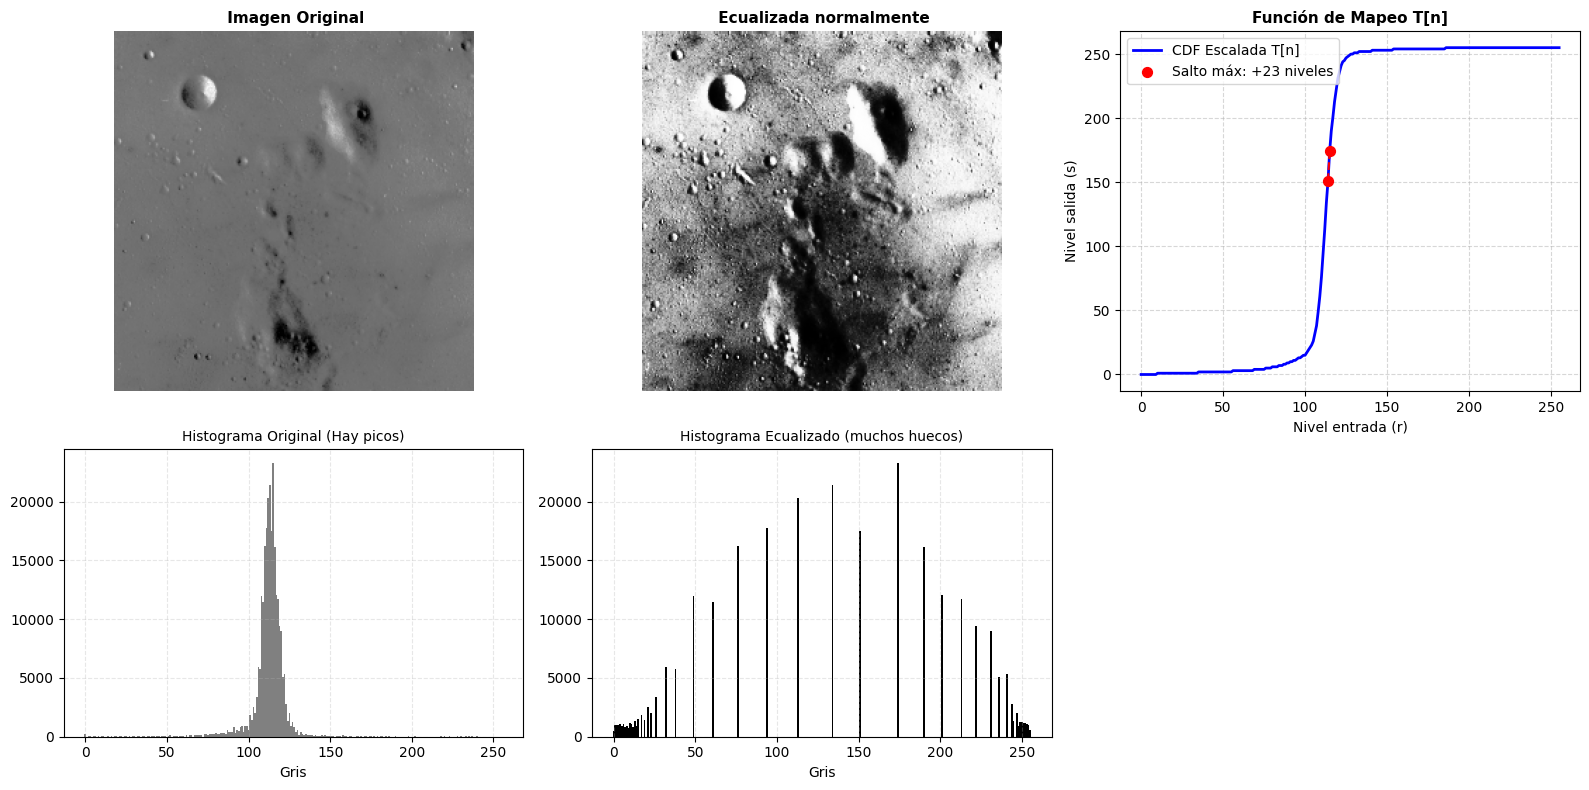

In [ ]:
img_prueba = data.moon()
resultado = diagnostico_ecualizacion(img_prueba)

print(f"Salto máximo de {resultado['max_salto_valor']} niveles detectado cerca del valor {resultado['puntos_salto'][0]}")

graficar_cambio_abrupto(resultado)

### 2.2 **Adjustable Histogram Equalization (AHE)**

La técnica de **Adjustable Histogram Equalization (AHE)** es una extensión de la ecualización de histograma tradicional, que permite **controlar el grado de ajuste** realizado sobre la imagen. A diferencia de la ecualización estándar, que tiende a generar grandes cambios abruptos en los valores de los píxeles, la **AHE** permite ajustar la intensidad de la transformación en función de un parámetro de ajuste, lo que resulta en una mayor flexibilidad y control sobre el contraste final de la imagen.


El procedimiento de la **AHE** se basa en resolver el siguiente problema de optimización:
$$ h = \arg \min_h \left( \|h - h_i\|_2^2 + \lambda \|h - u\|_2^2 \right) $$

Donde:

- **$h$** histograma normalizado de la imagen original.
- **$h_i$** es el histograma de entrada de la imagen original.
- **$u$** es el histograma uniforme.
- $\lambda \ge 0$: Factor de ponderación.
  - $\lambda = 0$: Se preserva el histograma original (sin cambios).
  - $\lambda \to \infty$: Se fuerza el histograma a ser uniforme (ecualización clásica).

In [ ]:
#Devuelve una Distribucion uniforme
def distribucionUniforme():
  return np.zeros(256) + 1.0/256.0

#Completar
def ecualizacionAjustable(imagen, lambdaArg):
  #PASO 1: Obtener el histograma original hi

  #PASO 2: Obtener el histograma uniforme u

  #PASO 3: Calcular el histograma óptimo h

  #PASO 4: Ecualizar la imagen con el nuevo histograma h
  return imagenEcualizada

In [ ]:
def visualizar_ahe(imagen, valores_lambda, titulo="AHE - Adjustable Histogram Equalization"):
    num_lambdas = len(valores_lambda)
    num_columnas = num_lambdas + 1

    fig = plt.figure(figsize=(3.8 * num_columnas, 10))
    gs = GridSpec(3, num_columnas, height_ratios=[1, 0.8, 1.1])
    fig.suptitle(titulo, fontsize=15, fontweight='bold')

    #---1era fila, 1era columna. Ponemos el histograma y la imagen original--
    ax_img_orig = fig.add_subplot(gs[0, 0])
    ax_img_orig.imshow(imagen, cmap='gray', vmin=0, vmax=255)
    ax_img_orig.set_title("Original", fontsize=11, fontweight='bold')
    ax_img_orig.axis('off')

    ax_hist_orig = fig.add_subplot(gs[1, 0])
    ax_hist_orig.hist(imagen.ravel(), bins=256, range=(0, 255), density=True, histtype='step', color='black', linewidth=1.2)
    ax_hist_orig.set_title("Hist. Original", fontsize=10)
    ax_hist_orig.set_xlabel("Nivel de gris")
    ax_hist_orig.set_ylabel("PDF")
    ax_hist_orig.grid(True, linestyle='--', alpha=0.4)

    #Calculamos la uniforme y la distribucion de la imagen
    hi = distribucionImagen(imagen)
    u = distribucionUniforme()

    ax_tn = fig.add_subplot(gs[2, :])
    ax_tn.plot(range(256), range(256), 'k--', alpha=0.5, label='Identidad (λ $\\to \\infty$)') #Ploteamos un grafo de mapeo
    colores = plt.cm.viridis(np.linspace(0.1, 0.9, num_lambdas))

    #Por cada lambda, vamos a poner su histograma e imagen
    for i, lam in enumerate(valores_lambda):
        col = i + 1

        img_ahe = ecualizacionAjustable(imagen, lam)

        #Recreamos la curva
        h_calculado = (1 / (1 + lam)) * hi + (lam / (1 + lam)) * u
        T_n = np.cumsum(h_calculado) * 255

        #Subplot Imagen
        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(img_ahe, cmap='gray', vmin=0, vmax=255)
        ax_img.set_title(f"λ = {lam}", fontsize=11, fontweight='bold')
        ax_img.axis('off')

        #Subplot Histograma
        ax_hist = fig.add_subplot(gs[1, col])
        ax_hist.hist(img_ahe.ravel(), bins=256, range=(0, 255), density=True, histtype='step', color=colores[i], linewidth=1.2)
        ax_hist.set_title(f"Hist. (λ = {lam})", fontsize=10)
        ax_hist.set_xlabel("Nivel de gris")
        ax_hist.grid(True, linestyle='--', alpha=0.4)

        #Trazo en la gráfica acumulada T[n]
        ax_tn.plot(range(256), T_n, color=colores[i], linewidth=2, label=f'T[n] (λ = {lam})')

    ax_tn.set_title("Evolución de la Función de Mapeo T[n]", fontsize=12, fontweight='bold')
    ax_tn.set_xlabel("Nivel de Entrada (r)")
    ax_tn.set_ylabel("Nivel de Salida (s)")
    ax_tn.set_xlim(0, 255)
    ax_tn.set_ylim(0, 255)
    ax_tn.grid(True, linestyle='--', alpha=0.4)
    ax_tn.legend(loc='upper left', framealpha=0.9)

    plt.tight_layout()
    return fig

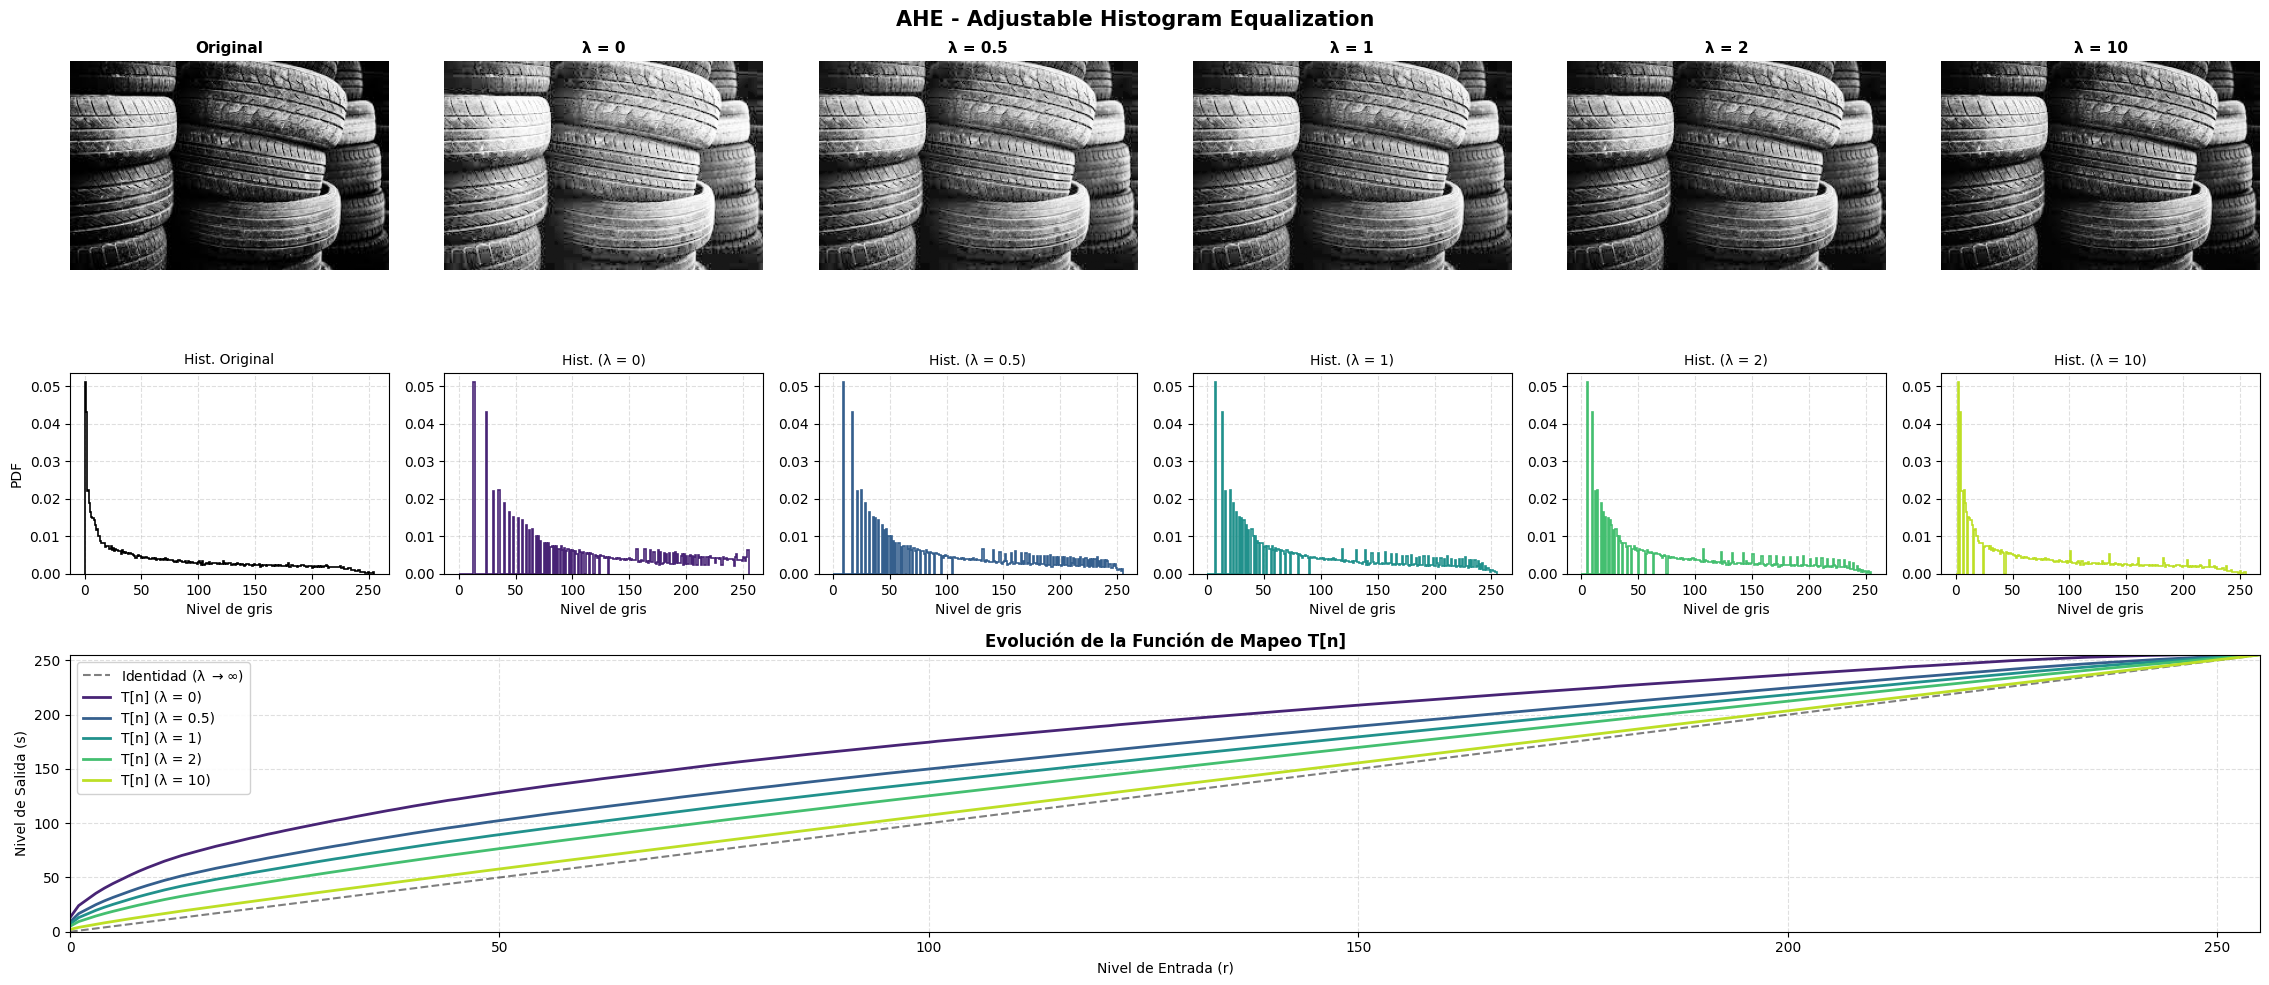

In [ ]:
imagenPocoContraste = util.img_as_ubyte(io.imread("neumaticos_2.jpg", as_gray=True))

lambdas = [0, 0.5,1, 2, 10]

fig = visualizar_ahe(imagenPocoContraste, lambdas)
plt.show()

### 2.3 **Histogram Smoothing**

El **suavizado de histograma** tiene como objetivo reducir la **rugosidad** o los **saltos abruptos** que pueden surgir en el histograma después de la ecualización. Estos saltos pueden resultar en una imagen con transiciones bruscas entre los niveles de gris, lo que puede producir un contraste poco natural. El suavizado se aplica para minimizar estas discontinuidades, logrando una **transición más suave** entre los valores de intensidad y, por lo tanto, un contraste más equilibrado y natural.

El proceso de suavizado de histograma se basa en la resolución de un problema de optimización, que balancea tres factores clave:

$$h = \arg \min_h \left( \Vert{}h - h_i\Vert{}_2^2 + \lambda \Vert{}h - u\Vert{}_2^2 + \gamma \Vert{}Dh\Vert{}_2^2 \right)$$

Donde:

- **$h$** es el histograma óptimo que buscamos
- **$h_i$** es el histograma de la imagen original normalizado.
- **$u$** es el histograma uniforme.
- **$D$** es la **matriz de diferencias**.
- $\lambda \ge 0$ (Peso de uniformidad): Regula el grado de ecualización. Valores elevados fuerzan a $h$ a aproximarse a una distribución uniforme, incrementando el contraste global de la imagen. Valores cercanos a cero priorizan la fidelidad al histograma original $h_i$.
- $\gamma \ge 0$ (Regularización de suavidad): Controla la continuidad del histograma mediante la penalización de diferencias abruptas entre bins contiguos ($Dh$). Un $\gamma$ alto produce transiciones tonales más suaves y naturales en la imagen, reduciendo artefactos; mientras que un $\gamma$ bajo (o nulo) conserva la estructura interna y rugosidades del histograma original.
- $D$ es la matriz de diferencias de primer orden (de tamaño $255 \times 256$), definida como:

$$D = \begin{bmatrix}
-1 & 1 & 0 & \dots & 0 \\
0 & -1 & 1 & \dots & 0 \\
\vdots & \ddots & \ddots & \ddots & \vdots \\
0 & \dots & 0 & -1 & 1
\end{bmatrix}$$

In [ ]:
#Devuelve la matriz de diferencia
def matrizDiferencia():
  return (np.diag(np.zeros(256) - 1, 0) + np.diag(np.zeros(255) + 1, 1))[:-1,:]

#Devuelve una Distribucion uniforme
def distribucionUniforme():
  return np.zeros(256) + 1.0/256.0

def suavizarHistograma(imagen, lambdaArg, gammaArg):
  """
  Aplica suavizado de histograma resolviendo:
    min_h  ||h - hi||^2 + λ||h - u||^2 + γ||D h||^2

  Parámetros:
      imagen: array uint8 (H, W) en escala de grises.
      lambdaArg: factor de uniformidad (≥ 0).
      gammaArg: factor de suavidad (≥ 0).

  Retorna:
      imagen ecualizada (uint8) con el histograma óptimo h.
    """
  #COMPLETAR
  #TIP: Resuelvan el sistema lineal de forma vectorizada con np.linalg.solve
  return imagenEcualizada, h_moño


In [ ]:
def visualizar_smoothing(imagen, parametros, titulo="Histogram Smoothing"):
    n = len(parametros)
    num_columnas = n + 1

    fig = plt.figure(figsize=(4 * num_columnas, 10))
    gs = GridSpec(3, num_columnas, height_ratios=[1, 0.8, 1.1])
    fig.suptitle(titulo, fontsize=16, fontweight='bold')

    #--1era fila, 1era columna. Ponemos la iamgen original y su histograma
    ax_img_orig = fig.add_subplot(gs[0, 0])
    ax_img_orig.imshow(imagen, cmap='gray', vmin=0, vmax=255)
    ax_img_orig.set_title("Original")
    ax_img_orig.axis('off')

    h0 = distribucionImagen(imagen)

    ax_hist_orig = fig.add_subplot(gs[1, 0])
    ax_hist_orig.fill_between(range(256), h0, color='gray', alpha=0.5)
    ax_hist_orig.plot(h0, color='black', linewidth=1)
    ax_hist_orig.set_title("h₀ (Original)")
    ax_hist_orig.grid(True, linestyle='--', alpha=0.4)

    ax_tn = fig.add_subplot(gs[2, :])

    #Calculamos su mapeo T[n]
    T_orig = np.cumsum(h0) * 255
    ax_tn.plot(range(256), T_orig, 'k--', alpha=0.6, label='T[n] Original (h₀)')

    colores = plt.cm.viridis(np.linspace(0.1, 0.9, n))

    #por cada uno de los parametros, vemos la iamgen y su histograma
    for i, (lam, gamma) in enumerate(parametros):
        col = i + 1

        img_smooth, h_moño = suavizarHistograma(imagen, lam, gamma)

        T_n = np.cumsum(h_moño) * 255

        #Subplot Imagen
        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(img_smooth, cmap='gray', vmin=0, vmax=255)
        ax_img.set_title(f"λ={lam}, γ={gamma}")
        ax_img.axis('off')

        #Subplot Histograma
        ax_hist = fig.add_subplot(gs[1, col])
        ax_hist.fill_between(range(256), h0, color='gray', alpha=0.3)
        ax_hist.plot(h_moño, color=colores[i], linewidth=2.5, label='h̃ suavizado')
        ax_hist.set_title(f"h̃ (λ={lam}, γ={gamma})")
        ax_hist.grid(True, linestyle='--', alpha=0.4)
        ax_hist.legend(fontsize=9, loc='upper right')

        #Trazo en la gráfica acumulada T[n]
        ax_tn.plot(range(256), T_n, color=colores[i], linewidth=2, label=f'T[n] (λ={lam}, γ={gamma})')

    ax_tn.set_title("Evolución de la Función de Mapeo T[n] (CDF)", fontsize=12, fontweight='bold')
    ax_tn.set_xlabel("Nivel de Entrada (r)")
    ax_tn.set_ylabel("Nivel de Salida (s)")
    ax_tn.set_xlim(0, 255)
    ax_tn.set_ylim(0, 255)
    ax_tn.grid(True, linestyle='--', alpha=0.4)
    ax_tn.legend(loc='upper left', framealpha=0.9)

    plt.tight_layout()
    return fig

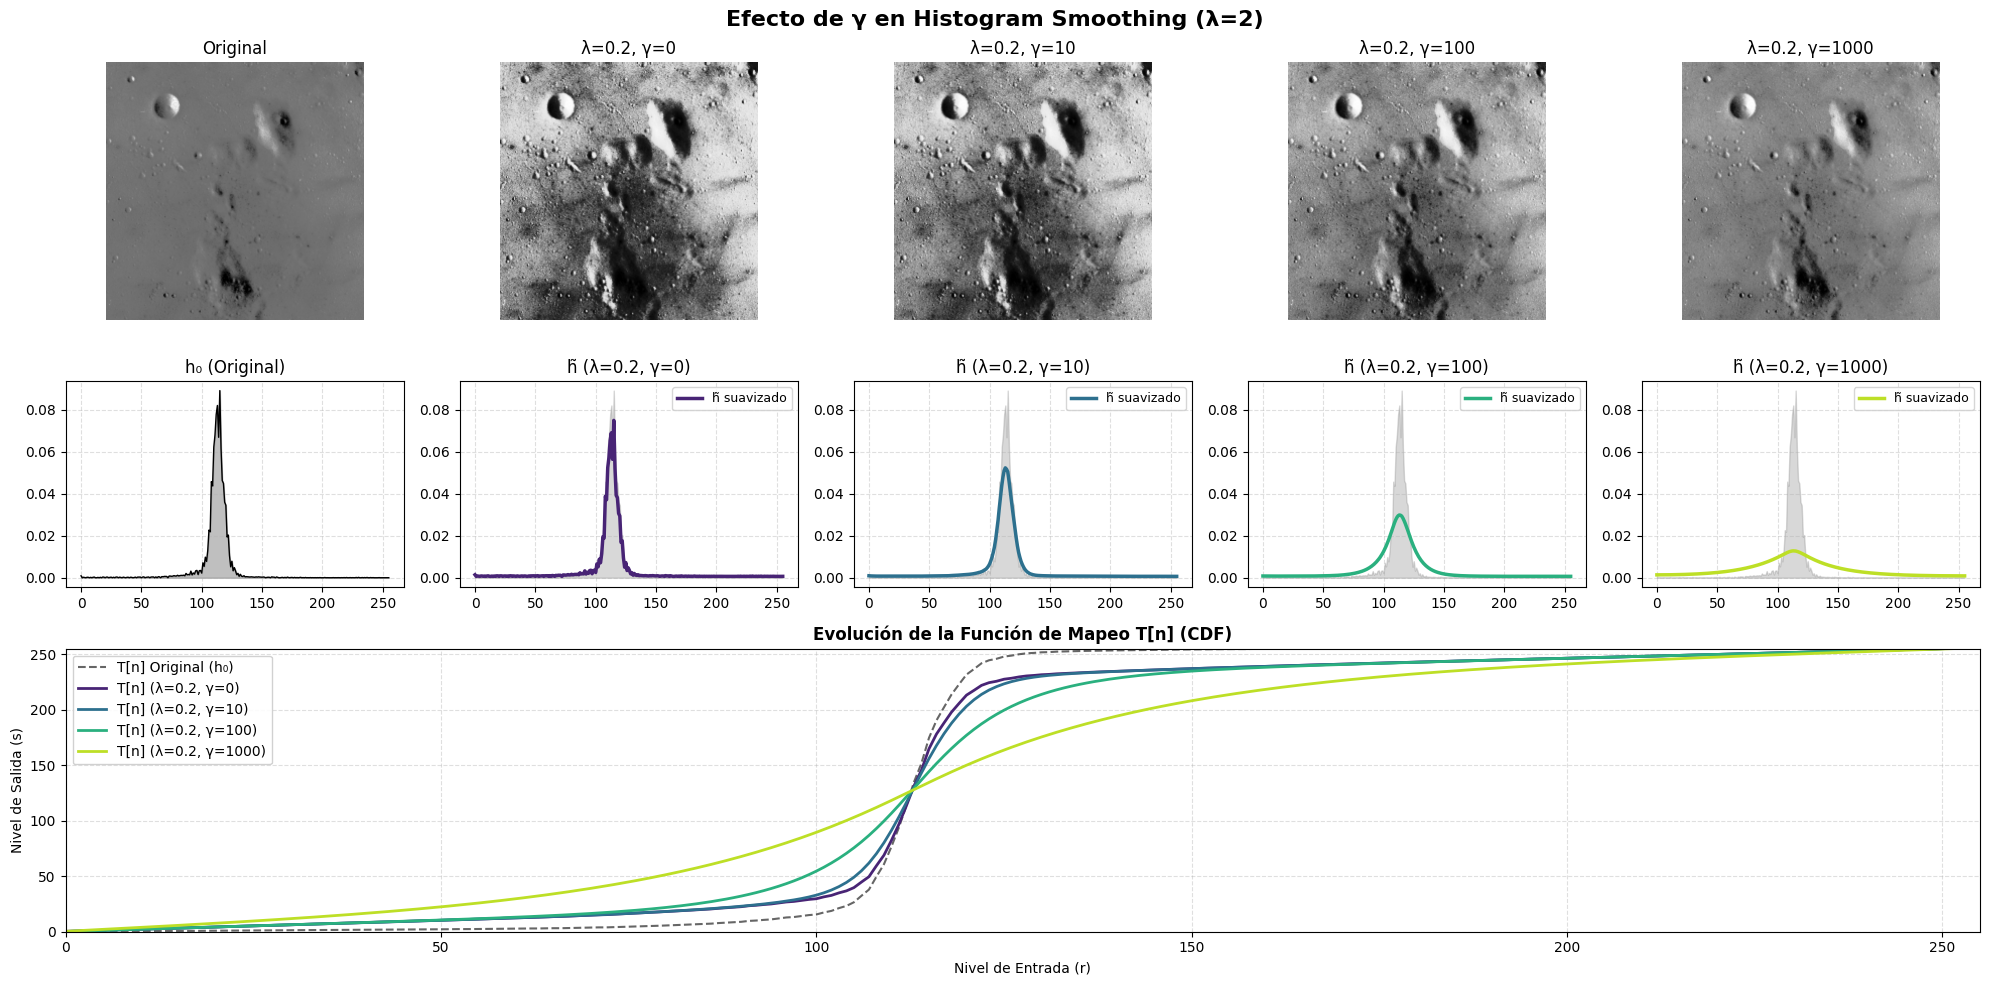

In [ ]:

parametros = [
    (0.2, 0),
    (0.2, 10),
    (0.2, 100),
    (0.2, 1000)
]
#imagen_ejemplo = util.img_as_ubyte(io.imread(skimage.data.moon(), as_gray=True))
fig = visualizar_smoothing(skimage.data.moon(), parametros, titulo="Efecto de γ en Histogram Smoothing (λ=2)")
plt.show()

### 2.4 **Black and White Stretching**

El **Black and White Stretching** (B&W Stretching) es una técnica utilizada para **expandir el rango dinámico** de una imagen, modificando la distribución de los niveles de gris. Su objetivo es acercar los valores de gris más oscuros al **negro** y los más brillantes al **blanco**, maximizando así el contraste sin perder la **naturalidad** de la imagen. Esta técnica permite ajustar el contraste de manera eficiente, estirando los valores de intensidad sin introducir distorsiones visuales agresivas, lo que resulta en una imagen con una mayor sensación de profundidad.


El procedimiento de B&W Stretching se basa en la resolución de un problema de optimización, que toma en cuenta tres términos fundamentales para equilibrar el ajuste del contraste y la preservación de la imagen original:

$$h = \arg\min_{h} \left( \Vert{}h - h_i\Vert{}_2^2 + \lambda \Vert{}h - u\Vert{}_2^2 + \alpha h^T I_B h \right)$$

Donde:

- **$h$**: histograma óptimo que buscamos.
- **$h_i$**: histograma normalizado de la imagen original.
- **$u$**: Es el histograma uniforme.
- **$\lambda$**: Es el **parámetro de ajuste** que regula la fuerza de la transformación. Un valor mayor de **$\lambda$** hace que el histograma resultante se acerque más al histograma uniforme, generando un contraste más pronunciado, mientras que un valor menor permite una mayor preservación de la estructura de la imagen original.
- **$\alpha$**: Es un parámetro que ajusta la **intensidad** del efecto del estiramiento. Un valor más alto de **$\alpha$** aumenta la extensión del estiramiento en los valores de gris, mientras que un valor bajo limita la cantidad de ajuste realizado.

- **$I^B$**: Es una matriz **diagonal** que contiene valores 1 en los rangos de gris que se desean estirar. Estos valores definen las áreas de la imagen que se verán más afectadas por el estiramiento, ampliando las intensidades de los píxeles en estos rangos.
- $$ [I_B]_{k,k} = \begin{cases}  1, & \text{si } k \le b \quad \text{o} \quad k \ge w \\  0, & \text{en otro caso}  \end{cases}$$

In [ ]:
def matrizEstiramiento(b, w):
  diagonal = np.zeros(256)
  diagonal[:b+1] = 1
  diagonal[w:256] = 1
  return np.diag(diagonal, 0)


def bwEstiramiento(imagen: np.ndarray, lambdaArg: float, alphaArg: float, b: int, w: int) -> np.ndarray:
  """
  Aplica Black & White Stretching resolviendo:
      min_h  ||h - hi||^2 + λ||h - u||^2 + α h^T I^B h

  Parámetros:
      imagen: array uint8 (H, W) en escala de grises.
      lambdaArg: factor de uniformidad (≥ 0).
      alphaArg: intensidad del estiramiento (≥ 0).
      b: umbral inferior (0 ≤ b < w ≤ 255) para estirar los tonos oscuros.
      w: umbral superior.

  Retorna:
      imagen ecualizada (uint8) con el histograma óptimo h.
  """
  #COMPLETAR
  return imagenEcualizada, h_moño

In [ ]:
def visualizar_bw(imagen, parametros, b, w, titulo="Black & White Stretching"):
    n = len(parametros)
    num_columnas = n + 1

    fig = plt.figure(figsize=(4 * num_columnas, 10))
    gs = GridSpec(3, num_columnas, height_ratios=[1, 0.8, 1.1])
    fig.suptitle(f"{titulo} (b={b}, w={w})", fontsize=16, fontweight='bold')

    #Imagen original y su histograma
    ax_img_orig = fig.add_subplot(gs[0, 0])
    ax_img_orig.imshow(imagen, cmap='gray', vmin=0, vmax=255)
    ax_img_orig.set_title("Original")
    ax_img_orig.axis('off')

    h0 = distribucionImagen(imagen)

    ax_hist_orig = fig.add_subplot(gs[1, 0])
    ax_hist_orig.fill_between(range(256), h0, color='gray', alpha=0.5)
    ax_hist_orig.plot(h0, color='black', linewidth=1)
    ax_hist_orig.axvline(b, color='red', linestyle=':', linewidth=1)
    ax_hist_orig.axvline(w, color='blue', linestyle=':', linewidth=1)
    ax_hist_orig.set_title("h₀ (Original)")
    ax_hist_orig.grid(True, linestyle='--', alpha=0.4)

    ax_tn = fig.add_subplot(gs[2, :])

    T_orig = np.cumsum(h0) * 255
    ax_tn.plot(range(256), T_orig, 'k--', alpha=0.6, label='T[n] Original (h₀)')
    ax_tn.axvline(b, color='red', linestyle=':', linewidth=1, label=f'b={b}')
    ax_tn.axvline(w, color='blue', linestyle=':', linewidth=1, label=f'w={w}')

    colores = plt.cm.viridis(np.linspace(0.1, 0.9, n))

    #Por cada parametro, agregamos su histograma e imagen
    for i, (lam, alpha) in enumerate(parametros):
        col = i + 1

        img_bw, h_moño = bwEstiramiento(imagen, lam, alpha, b, w)
        T_n = np.cumsum(h_moño) * 255

        #Subplot Imagen
        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(img_bw, cmap='gray', vmin=0, vmax=255)
        ax_img.set_title(f"λ={lam}, α={alpha}")
        ax_img.axis('off')

        #Subplot Histograma
        ax_hist = fig.add_subplot(gs[1, col])
        ax_hist.fill_between(range(256), h0, color='gray', alpha=0.3)
        ax_hist.plot(h_moño, color=colores[i], linewidth=2.5, label='h̃ estirado')
        ax_hist.axvline(b, color='red', linestyle=':', linewidth=1)
        ax_hist.axvline(w, color='blue', linestyle=':', linewidth=1)
        ax_hist.set_title(f"h̃ (λ={lam}, α={alpha})")
        ax_hist.grid(True, linestyle='--', alpha=0.4)
        ax_hist.legend(fontsize=9, loc='upper right')

        ax_tn.plot(range(256), T_n, color=colores[i], linewidth=2, label=f'T[n] (λ={lam}, α={alpha})')

    ax_tn.set_title("Evolución de la Función de Mapeo T[n] (CDF)", fontsize=12, fontweight='bold')
    ax_tn.set_xlabel("Nivel de Entrada (r)")
    ax_tn.set_ylabel("Nivel de Salida (s)")
    ax_tn.set_xlim(0, 255)
    ax_tn.set_ylim(0, 255)
    ax_tn.grid(True, linestyle='--', alpha=0.4)
    ax_tn.legend(loc='upper left', framealpha=0.9, fontsize=8)

    plt.tight_layout()
    return fig

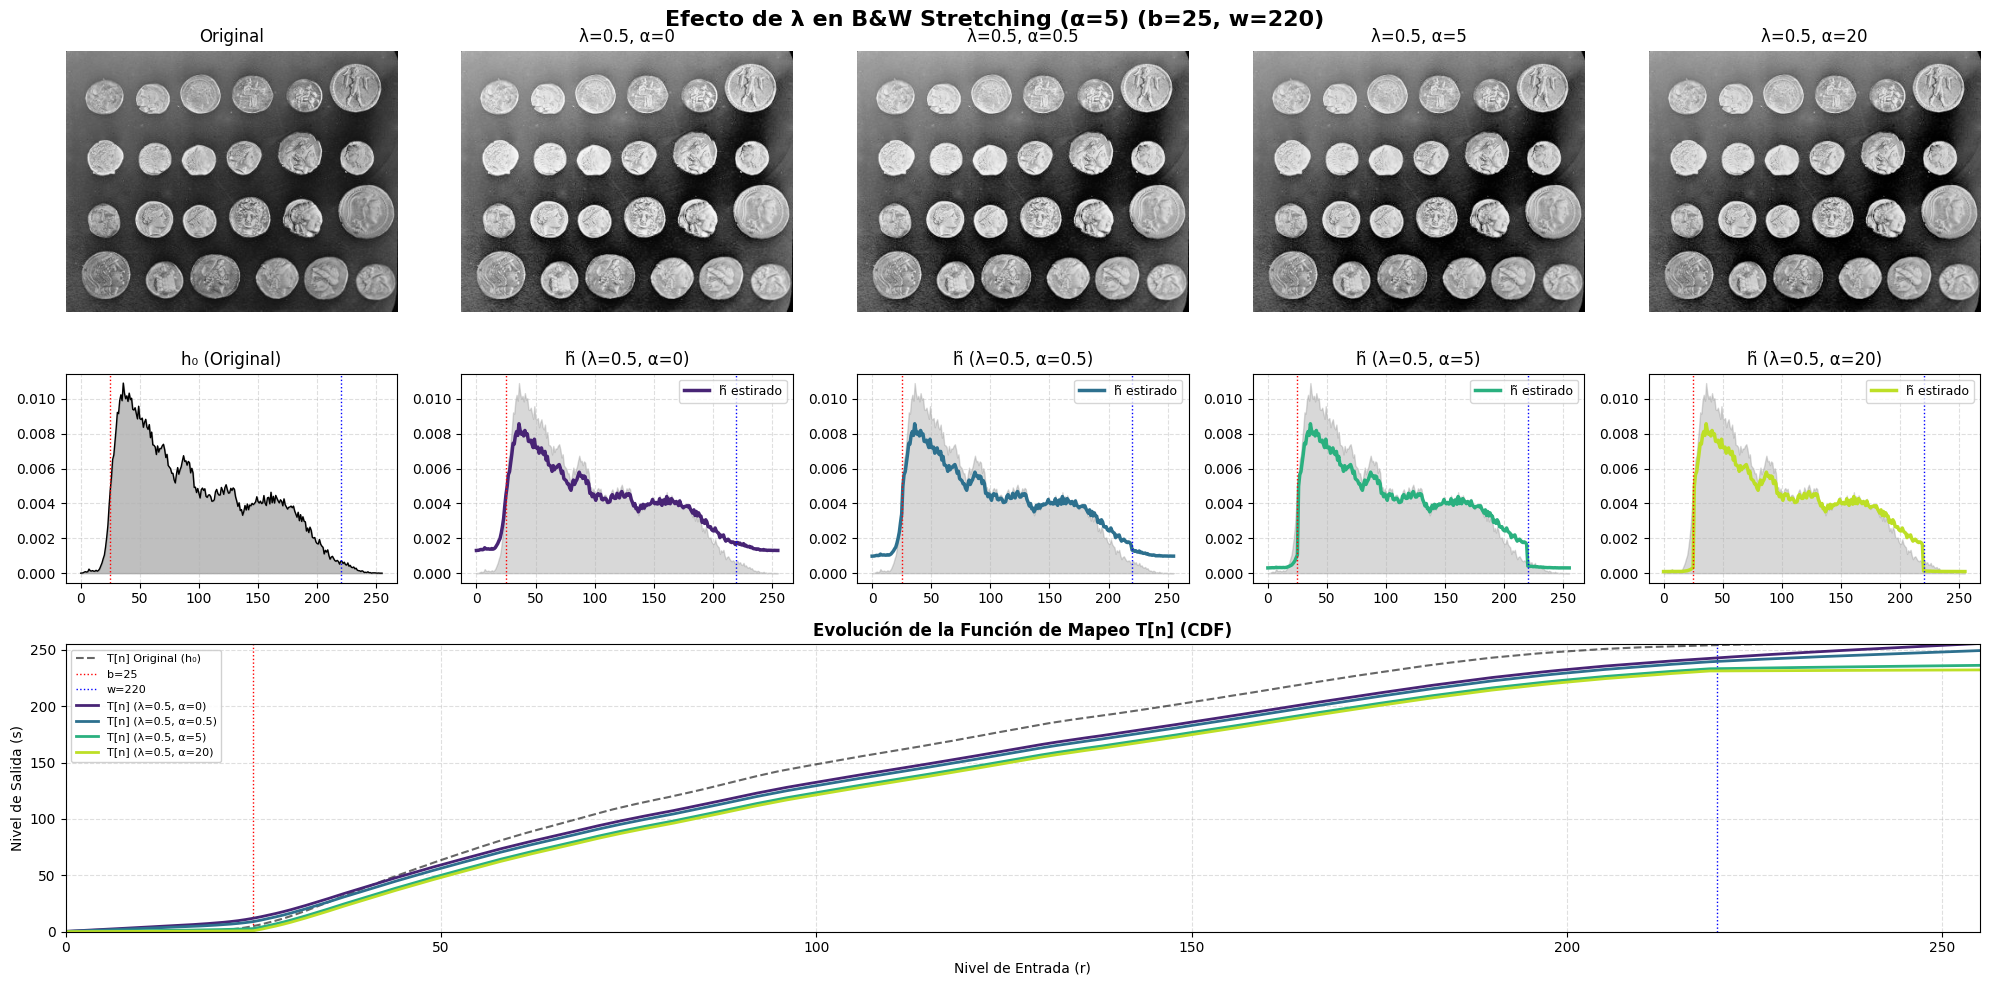

In [ ]:
ejemplo = util.img_as_ubyte(io.imread("fog.jpeg", as_gray=True))

lambda_fijo = 0.5
parametros_alpha = [
    (lambda_fijo, 0),
    (lambda_fijo, 0.5),
    (lambda_fijo, 5),
    (lambda_fijo, 20)
]

fig = visualizar_bw(skimage.data.coins(), parametros_alpha , b=25, w=220, titulo="Efecto de λ y α en B&W Stretching")
plt.show()

### 2.5 **GCE Histogram Modification Algorithm**

El algoritmo final propuesto por el artículo **GCE Histogram Modification Algorithm** propone unas heurísticas claras para obtener valores óptimos en los hiperparámetros del ajuste de contraste. Por otro lado, también ofrece una estrategia computacionalmente barata para suavizar picos en la imagen de salida.

Ya que los picos suceden por estadísticas infladas causadas por grandes zonas homogéneas, una manera de evitar darles tanta importancia en el histograma optimizado es simplemente ignorar a los píxeles que se encuentran en estas grandes zonas homogéneas.

### Procedimiento

El procedimiento de **GCE Histogram Modification Algorithm** se basa en la anterior definición de **Black and White Stretching**, encontrando los mejores parámetros según características propias de la imagen.

![Alt text](https://github.com/StrawEater/PracticasPDI3erBimestre/blob/main/Tareas/Tarea_1/image.png?raw=true)

### Parámetros y variables

**Hiperparámetros fijos**

| Símbolo | Descripción | Valor |
|---|---|---|
| $Threshold$ | Umbral mínimo de diferencia entre dos píxeles vecinos para ser considerados no homogéneos | 5 |
| $g$ | Escala $k$ | 10 |
| $u_{min}$ | Mínimo valor que puede contener cada bin del histograma uniforme. Rompe las reglas de una distribución, pero mejora el rango dinámico | 10 |
| $\alpha$ | Ajusta la **intensidad** del efecto del estiramiento | 2 |

**Variables calculadas**

| Símbolo | Descripción |
|---|---|
| $k$ | Nivel de contraste en la imagen original. Se calcula acumulando la diferencia de cada píxel con su vecino |
| $h_i$ | Histograma de la imagen original ignorando las zonas homogéneas |
| $count$ | Cantidad de píxeles que no forman parte de zonas homogéneas |
| $k^*$ | $g \cdot k$ normalizado contra un valor máximo definido: la primera potencia de dos mayor a $g \cdot k$ |
| $u$ | Histograma uniforme |
| $b$ | Mínima intensidad del histograma con una mínima cantidad de píxeles (1% de los pixeles) |
| $w$ | Máxima intensidad del histograma con una mínima cantidad de píxeles (1% de los pixeles) |

In [ ]:
def GCEHistMod(imagen: np.ndarray) -> np.ndarray:
  """
  Aplica GCEHistMod:

  Parámetros:
      imagen: array uint8 (H, W) en escala de grises.

  Retorna:
      imagen ecualizada (uint8) con el histograma óptimo h.
  """
  #COMPLETAR
  return imagenEcualizada, h_moño

In [ ]:
def visualizar_bw(imagen, titulo="GCE Histogram Modification"):

    n = 1
    num_columnas = n + 1

    fig = plt.figure(figsize=(4 * num_columnas, 10))
    gs = GridSpec(3, num_columnas, height_ratios=[1, 0.8, 1.1])
    fig.suptitle(f"{titulo}", fontsize=16, fontweight='bold')

    #Imagen original y su histograma
    ax_img_orig = fig.add_subplot(gs[0, 0])
    ax_img_orig.imshow(imagen, cmap='gray', vmin=0, vmax=255)
    ax_img_orig.set_title("Original")
    ax_img_orig.axis('off')

    h0 = distribucionImagen(imagen)

    ax_hist_orig = fig.add_subplot(gs[1, 0])
    ax_hist_orig.fill_between(range(256), h0, color='gray', alpha=0.5)
    ax_hist_orig.plot(h0, color='black', linewidth=1)
    ax_hist_orig.axvline(b, color='red', linestyle=':', linewidth=1)
    ax_hist_orig.axvline(w, color='blue', linestyle=':', linewidth=1)
    ax_hist_orig.set_title("h₀ (Original)")
    ax_hist_orig.grid(True, linestyle='--', alpha=0.4)

    ax_tn = fig.add_subplot(gs[2, :])

    T_orig = np.cumsum(h0) * 255
    ax_tn.plot(range(256), T_orig, 'k--', alpha=0.6, label='T[n] Original (h₀)')
    ax_tn.axvline(b, color='red', linestyle=':', linewidth=1, label=f'b={b}')
    ax_tn.axvline(w, color='blue', linestyle=':', linewidth=1, label=f'w={w}')

    colores = plt.cm.viridis(np.linspace(0.1, 0.9, n))

    col = 1
    img_bw, h_moño = GCEHistMod(imagen)
    T_n = np.cumsum(h_moño) * 255

    #Subplot Imagen
    ax_img = fig.add_subplot(gs[0, col])
    ax_img.imshow(img_bw, cmap='gray', vmin=0, vmax=255)
    ax_img.set_title(f"GCE Hist Modification Ecualization")
    ax_img.axis('off')

    #Subplot Histograma
    ax_hist = fig.add_subplot(gs[1, col])
    ax_hist.fill_between(range(256), h0, color='gray', alpha=0.3)
    ax_hist.plot(h_moño, color=colores[i], linewidth=2.5, label='h̃ estirado')
    ax_hist.axvline(b, color='red', linestyle=':', linewidth=1)
    ax_hist.axvline(w, color='blue', linestyle=':', linewidth=1)
    ax_hist.set_title(f"GCE Hist Modification Ecualization")
    ax_hist.grid(True, linestyle='--', alpha=0.4)
    ax_hist.legend(fontsize=9, loc='upper right')

    ax_tn.plot(range(256), T_n, color=colores[i], linewidth=2, label=f'T[n] (GCE Hist Modification Ecualization)')

    ax_tn.set_title("Evolución de la Función de Mapeo T[n] (CDF)", fontsize=12, fontweight='bold')
    ax_tn.set_xlabel("Nivel de Entrada (r)")
    ax_tn.set_ylabel("Nivel de Salida (s)")
    ax_tn.set_xlim(0, 255)
    ax_tn.set_ylim(0, 255)
    ax_tn.grid(True, linestyle='--', alpha=0.4)
    ax_tn.legend(loc='upper left', framealpha=0.9, fontsize=8)

    plt.tight_layout()
    return fig

In [ ]:
ejemplo = util.img_as_ubyte(io.imread("fog.jpeg", as_gray=True))

fig = visualizar_bw(skimage.data.coins(), titulo="GCE Hist Modification Ecualization")
plt.show()

## 3. Consigna Final



Reflexionen sobre qué tipo de imágenes podrían beneficiarse de este marco de modificación de histogramas en el mundo real (satelitales, escaneos médicos, retratos, paisajes, etc.).

### 3.1 Elección del tipo de imagen

Elijan un tipo de imagen y busquen al menos **5 ejemplos** en donde sea necesario aplicar una mejora de contraste.



### 3.2 Búsqueda de hiperparámetros

Realicen una búsqueda de hiperparámetros para el algoritmo **Histogram Smoothing** sobre $\lambda$ y $\gamma$, encontrando los mejores valores que se adapten al tipo de imagen elegido.

Durante la búsqueda, calculen las siguientes métricas:

- Promedio de intensidad
- Varianza
- Percentil 25
- Percentil 75
- Measure of Enhancement (EME)

Vinculen los diferentes valores y cambios en las métricas con los cambios visuales observados en la imagen.



In [ ]:
def eme(image, block_size=(8, 8), eps=1e-6):
    """
    Calcula la métrica EME (Measure of Enhancement) de una imagen en escala de grises.

    La EME divide la imagen en bloques no solapados y promedia
    20 * log10(I_max / I_min) sobre todos los bloques, aproximando el
    contraste local promedio de la imagen. A mayor EME, mayor contraste.

    Referencia: Agaian, S. S., Panetta, K., & Grigoryan, A. M. (2001).
    A new measure of image enhancement.

    Parameters
    ----------
    image : np.ndarray
        Imagen 2D en escala de grises (cualquier dtype numérico).
    block_size : tuple(int, int)
        Alto y ancho de cada bloque, por ejemplo (8, 8).
    eps : float
        Constante pequeña sumada a I_max e I_min para evitar log(0) o
        división por cero en bloques totalmente homogéneos (I_min == 0).

    Returns
    -------
    float
        El valor de EME.
    """
    image = np.asarray(image, dtype=np.float64)
    if image.ndim != 2:
        raise ValueError("image debe ser 2D (escala de grises)")

    h, w = image.shape
    bh, bw = block_size

    n_blocks_h = h // bh
    n_blocks_w = w // bw

    if n_blocks_h == 0 or n_blocks_w == 0:
        raise ValueError("block_size es mas grande que la imagen")

    # Recorta la imagen para que quede un numero entero de bloques
    # (descarta el resto de filas/columnas que no completan un bloque)
    image = image[: n_blocks_h * bh, : n_blocks_w * bw]

    # Reorganiza la imagen en bloques: shape final (n_blocks_h, n_blocks_w, bh, bw)
    blocks = image.reshape(n_blocks_h, bh, n_blocks_w, bw).swapaxes(1, 2)

    i_max = blocks.max(axis=(2, 3))
    i_min = blocks.min(axis=(2, 3))

    ratios = 20 * np.log10((i_max + eps) / (i_min + eps))

    return float(ratios.mean())

### 3.3 Comparación con GCE

Comparen las imágenes resultantes con sus hiperparámetros optimizados contra el output de aplicar el **GCE Histogram Modification Algorithm**.

Decidan cuál técnica dio mejores resultados, utilizando las métricas calculadas para respaldar su respuesta.